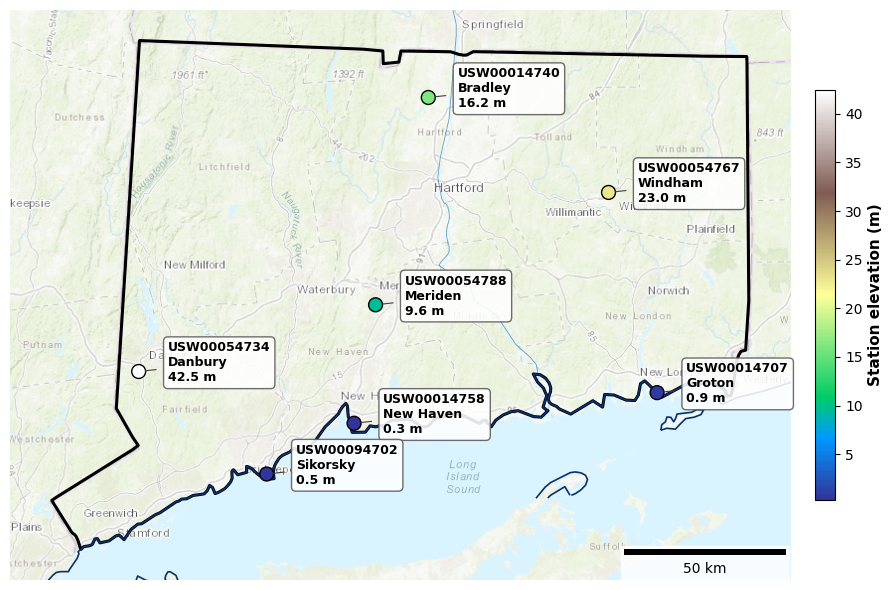

In [1]:
import geopandas as gpd
import contextily as ctx
import matplotlib as mpl
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib_scalebar.scalebar import ScaleBar

stations = {
    'USW00014707': {'lat': 41.3275, 'lon': -72.0494, 'elev': 3.0 * 0.3048, 'city': 'Groton'},
    'USW00014740': {'lat': 41.9375, 'lon': -72.6819, 'elev': 53.3 * 0.3048, 'city': 'Bradley'},
    'USW00014758': {'lat': 41.2639, 'lon': -72.8872, 'elev': 0.9 * 0.3048, 'city': 'New Haven'},
    'USW00054734': {'lat': 41.3714, 'lon': -73.4828, 'elev': 139.3 * 0.3048, 'city': 'Danbury'},
    'USW00054767': {'lat': 41.7419, 'lon': -72.1836, 'elev': 75.3 * 0.3048, 'city': 'Windham'},
    'USW00054788': {'lat': 41.5097, 'lon': -72.8278, 'elev': 31.4 * 0.3048, 'city': 'Meriden'},
    'USW00094702': {'lat': 41.1583, 'lon': -73.1289, 'elev': 1.5 * 0.3048, 'city': 'Sikorsky'},
}

records = [{'id': id, 'geometry': Point(info['lon'], info['lat']), 'elev': info['elev'], 'city': info['city']} for id, info in stations.items()]
stations_gdf = gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326').to_crs('EPSG:3857')

# Get state boundary, rivers, and coastline
states = gpd.read_file('https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip')
rivers = gpd.read_file('https://naciscdn.org/naturalearth/10m/physical/ne_10m_rivers_lake_centerlines.zip')
coastline = gpd.read_file('https://naciscdn.org/naturalearth/10m/physical/ne_10m_coastline.zip')

ct_state = states[(states['name'] == 'Connecticut') & (states['admin'] == 'United States of America')].to_crs('EPSG:3857')
map_region = ct_state.geometry.iloc[0].buffer(25000)
ct_rivers = rivers.to_crs('EPSG:3857').clip(map_region)
ct_coastline = coastline.to_crs('EPSG:3857').clip(map_region)

# Plot state polygon, rivers, and coastline
fig, ax = plt.subplots(figsize=(10, 6))
ct_state.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2.2, zorder=5)
ct_rivers.plot(ax=ax, color='#2b83ba', linewidth=0.6, alpha=0.75, zorder=4)
ct_coastline.plot(ax=ax, color='#08306b', linewidth=1.2, zorder=5)

# Add terrain basemap
terrain_basemap = ctx.providers.Esri.WorldTopoMap
ctx.add_basemap(ax, source=terrain_basemap, zoom=9, alpha=0.72, attribution=False)

# Plot weather stations using elevation color
elevations = stations_gdf['elev'].values
norm = mpl.colors.Normalize(vmin=elevations.min(), vmax=elevations.max())
stations_gdf.plot(ax=ax, column='elev', cmap='terrain', norm=norm, markersize=100, edgecolor='black', zorder=10)

# Add station labels
for _, row in stations_gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y
    ax.annotate(f'{row['id']}\n{row['city']}\n{row['elev']:.1f} m', xy=(x, y), xytext=(x+9e3, y-3e3), fontsize=9, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.35', alpha=0.88), 
                arrowprops=dict(arrowstyle='-', color='0.25', linewidth=0.8, shrinkA=5, shrinkB=5), zorder=20)

# Add elevation colorbar
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='terrain'), ax=ax, shrink=0.72, pad=0.025)
cbar.set_label('Station elevation (m)', fontsize=11, fontweight='bold')

# Map extent
xmin, ymin, xmax, ymax = ct_state.total_bounds
x_margin = (xmax - xmin) * 0.06
y_margin = (ymax - ymin) * 0.06
ax.set_xlim(xmin - x_margin, xmax + x_margin)
ax.set_ylim(ymin - y_margin, ymax + y_margin)
ax.set_axis_off()

# Add scale bar
ax.add_artist(ScaleBar(1, units='m', length_fraction=0.25, location='lower right', box_alpha=0.8))

plt.tight_layout()
# plt.savefig('study_area.pdf', bbox_inches='tight')
plt.show()

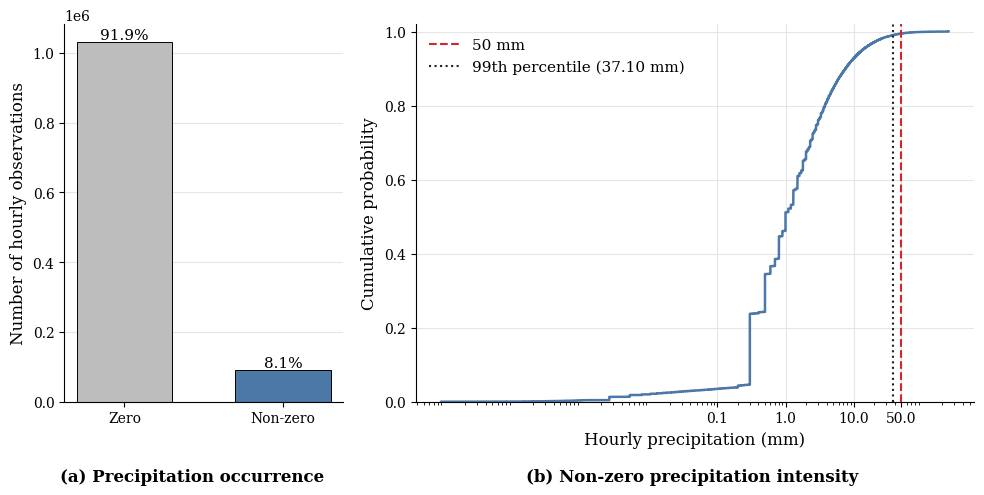

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from config import *
from preprocess import load_all_stations
from matplotlib.ticker import ScalarFormatter

# Load data
all_df = load_all_stations(DATA_DIR)
prcp = all_df['prcp'].dropna()
prcp_nonzero = prcp[prcp > 0]

# Figure setting
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'savefig.dpi': 1200,
    'savefig.bbox': 'tight',
})

fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 2]})

# Panel (a): zero/non-zero occurrence
ax = axes[0]
counts = [(prcp == 0).sum(), (prcp > 0).sum()]
labels = ['Zero', 'Non-zero']
bars = ax.bar(labels, counts, width=0.6, color=['#BDBDBD', '#4C78A8'], edgecolor='black', linewidth=0.7)

for bar, count in zip(bars, counts):
    pct = count / len(prcp) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Number of hourly observations')
ax.grid(axis='y', color='0.90')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)

# Panel (b): ECDF of non-zero precipitation
ax = axes[1]
x = np.sort(prcp_nonzero)
y = np.arange(1, len(x)+1) / len(x)
q99 = prcp_nonzero.quantile(0.99)

ax.step(x, y, where='post', color='#4C78A8', linewidth=1.8)
ax.axvline(50, color='#D62728', linestyle='--', label='50 mm')
ax.axvline(q99, color='#222222', linestyle=':', label=f'99th percentile ({q99:.2f} mm)')

ax.set_xscale('log')
ax.set_xticks([0.1, 1, 10, 50])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_ylim(0, 1.02)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_xlabel('Hourly precipitation (mm)')
ax.set_ylabel('Cumulative probability')
ax.legend(frameon=False, loc='upper left')

ax.grid(axis='both', color='0.90')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)

# Panel captions
fig.text(0.2, 0.02, '(a) Precipitation occurrence', ha='center', fontweight='bold')
fig.text(0.7, 0.02, '(b) Non-zero precipitation intensity', ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig('prcp_dist.png')
plt.show()